#### Group members:
#### - CHERYL CHEONG KAH VOON (A23CS0060)
#### - SYARIFAH DANIA BINTI SYED ABU BAKAR (A23CS0183)
#### - WOO CHENG SHUAN (A23CS0283)
#### - YASMIN BATRISYIA BINTI ZAHIRUDDIN (A23CS0201)

# Project Overview
## 1.1 Introduction
An urgent environmental problem is the increase in carbon dioxide (CO₂) emissions worldwide brought on by the growing number of vehicles on the road. Cars contribute significantly to the transportation industry, which is one of the biggest sources of greenhouse gas emissions. Policymakers, automakers and customers may all make better decisions to reduce their influence on the environment by knowing the emission trends of various car models and makes. 

To learn more about fuel consumption, emission trends, and high-emission vehicle categories, this research focuses on evaluating vehicle emissions data. The project intends to investigate the connection between car attributes and their environmental impact by utilizing machine learning techniques and Python-based data analytics tools. In order to produce insightful visualizations and predictive insights, this end-to-end data analytics project places a strong emphasis on both data preparation and sophisticated analytics approaches. 

## 1.2 Project Objectives
The objectives of this project are as follows: 
- To explore and clean two datasets related to vehicle fuel consumption and CO₂ emissions. 
- To integrate data from FuelConsumption.csv and Cars2025.scv to create a unified dataset for analysis. 
- To perform data wrangling, feature engineering and aggregation to prepare the data for analytics. 
- To apply descriptive analytics and visualize trends in emissions by vehicle type, brand and fuel usage. 
- To implement machine learning techniques to group car models based on their emission levels. 
- To generate a 10-minute group video presentation summarizing the analysis, insights and recommendations. 
- To foster teamwork and collaboration in a real-world data analytics scenario.

#### Research Questions
This project aims to address the following key questions:
1. How do vehicle characteristics (e.g., engine size, fuel type) correlate with CO₂ emissions?
2. Which car brands/models exhibit the highest and lowest emissions and what trends emerge?
3. How do different fuel types affect CO₂ emissions in vehicles?
4. What is the distribution of CO₂ emissions accross different vehicle classes (e.g., SUVs, sedans, hybrids), and which class contributes the most to emissions?

## 1.3 Dataset Description
This project utilizes two real-world datasets related to vehicle fuel consumption and registrations:

**i. FuelConsumption.csv**
- **Source:** Environment Canada (2014 vehicle models).  
- **Key Columns:** `Make`, `Model`, `EngineSize`, `FuelType`, `CO2Emissions`.  
- **Purpose:** Analyze how vehicle specs impact emissions (Research Questions 1, 3).  

**ii. Cars2025.csv**  
- **Source:** Malaysian Transport Ministry (2025 registrations).  
- **Key Columns:** `Maker` (renamed to `Make`), `Model`, `Fuel`, `State`.  
- **Purpose:** Match 2025 registrations with 2014 emission data to study trends (Research Questions 2, 4).  
- **Limitation:** No direct 2025 emission data; assumed similar trends to 2014. 

# Phase 1 Data Preparation and Cleaning

#### Step 1:
Prepare both datasets and match the car registration from Cars2025.csv with the information on the carbon emissions from FuelConsumption.csv
## 2.1 Importing Datasets
In this step, we load the datasets FuelConsumption.csv and Cars2025.csv using pandas. These datasets form the foundation for our analysis:
- **FuelConsumption.csv**: Contains 2014 Canadian vehicle data, including CO₂ emissions, fuel consumption, and technical specifications.
- **Cars2025.csv**: Contains simulated 2025 Malaysian vehicle registration data, including make, model, registration number, and location.

In [8]:


import pandas as pd

cars_df = pd.read_csv("cars_2025.csv")
fuel_df = pd.read_csv("FuelConsumption.csv")
print(cars_df.shape)
print(fuel_df.shape)


(263578, 7)
(1067, 13)


## 2.2 Dataset Inspection
Before any processing, we inspect the data to understand its structure and quality:
- **Check data types**: Ensures numerical and categorical columns are recognized correctly.
- **Check for nulls and duplicates**: Identify missing values or duplicate rows that could affect analysis.
- **Basic statistics**: Summary of numerical columns (describe()), and data balance in categorical columns.

In [10]:
print("Cars Dataset Shape:", cars_df.shape)
cars_df.head()

print("Fuel Dataset Shape:", fuel_df.shape)
fuel_df.head()

Cars Dataset Shape: (263578, 7)
Fuel Dataset Shape: (1067, 13)


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


#### Step 2: 
Do appropriate data cleaning, preparation and wrangling
## 2.3 Data Merging and Matching
We merge the two datasets to create a unified view for analysis. Since both datasets share Make and Model, we perform a left join from the Cars2025.csv dataset to enrich it with emissions and fuel consumption data.

Before merging:
- Standardize column names (case, whitespace)
- Remove trailing spaces in Make or Model
- Convert to lowercase (optional, for matching)

In [12]:
cars_df.columns = cars_df.columns.str.strip().str.lower().str.replace(' ', '_')
fuel_df.columns = fuel_df.columns.str.strip().str.lower().str.replace(' ', '_')

#Ensure the maker in cars_df is same with make
cars_df.rename(columns={'maker': 'make'}, inplace=True)


## 2.4 Data Cleaning and Handling Missing Values
We clean the merged dataset by:
- Removing rows with missing CO₂ emissions or engine size
- Dropping duplicate rows
- Ensuring numerical columns are in the correct format (e.g., float)

In [14]:
for df in [cars_df, fuel_df]:
    df['make'] = df['make'].str.upper().str.strip()
    df['model'] = df['model'].str.upper().str.strip()

# Drop exact duplicate rows
cars_df.drop_duplicates(inplace=True)
fuel_df.drop_duplicates(inplace=True)

# Merge datasets on make and model
merged_df = pd.merge(cars_df, fuel_df, on=['make', 'model'], how='inner')

# Drop rows with missing values (if have)
merged_df.dropna(inplace=True)

# Show results
print("Cleaned and Merged Dataset Shape:", merged_df.shape)
merged_df.head(15)

Cleaned and Merged Dataset Shape: (9212, 18)


,date_reg,type,make,model,colour,fuel,state,modelyear,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,2025-01-01,motokar,PORSCHE,911 CARRERA,grey,petrol,Johor,2014,MINICOMPACT,3.4,6,AM7,Z,11.6,8.3,10.1,28,232
1,2025-01-01,motokar,PORSCHE,911 CARRERA,grey,petrol,Johor,2014,MINICOMPACT,3.4,6,M7,Z,12.5,8.6,10.7,26,246
2,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Selangor,2014,COMPACT,1.8,4,AV,X,7.9,6.0,7.0,40,161
3,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Selangor,2014,COMPACT,1.8,4,AV7,X,8.1,6.2,7.2,39,166
4,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Selangor,2014,COMPACT,1.8,4,M5,X,8.5,6.6,7.6,37,175
5,2025-01-02,motokar,HONDA,CIVIC,blue,petrol,Selangor,2014,COMPACT,1.8,4,AV,X,7.9,6.0,7.0,40,161
6,2025-01-02,motokar,HONDA,CIVIC,blue,petrol,Selangor,2014,COMPACT,1.8,4,AV7,X,8.1,6.2,7.2,39,166
7,2025-01-02,motokar,HONDA,CIVIC,blue,petrol,Selangor,2014,COMPACT,1.8,4,M5,X,8.5,6.6,7.6,37,175
8,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Rakan Niaga,2014,COMPACT,1.8,4,AV,X,7.9,6.0,7.0,40,161
9,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Rakan Niaga,2014,COMPACT,1.8,4,AV7,X,8.1,6.2,7.2,39,166


#### Step 3: 
Do appropriate data aggregation and group operations
## 2.5 Data Aggregation and Group Operations
Now we structure the data to answer **Research Questions**:

#### # 1. How do vehicle characteristics (e.g., engine size, fuel type) correlate with CO2 emissions?
- **Engine Size** tends to have a positive correlation with CO₂ emissions. That means bigger engines will burned more fuel and have higher emissions.
- Vehicles using diesel or premium **fuel type** typically emit more CO₂ than those using regular gasoline or hybrids.

#### # 2. Which car brands/models exhibit the highest and lowest emissions and what trends emerge?

In [16]:
top_makes = merged_df.groupby('make')['co2emissions'].mean().sort_values(ascending=False).reset_index()
print("Top 5 highest CO₂ emission brands:")
display(top_makes.head())

print("Top 5 lowest CO₂ emission brands:")
display(top_makes.tail())

avg_emissions_by_model = merged_df.groupby(['make', 'model'])['co2emissions'].mean().reset_index().sort_values(by='co2emissions', ascending=False).reset_index(drop=True)
print("Top 5 models with highest CO₂ emissions:")
display(avg_emissions_by_model.head())

print("Top 5 models with lowest CO₂ emissions:")
display(avg_emissions_by_model.tail())

Top 5 highest CO₂ emission brands:


,make,co2emissions
0,ASTON MARTIN,359.000000
1,BENTLEY,348.600000
2,MASERATI,347.000000
3,NISSAN,297.000000
4,PORSCHE,281.244635


Top 5 lowest CO₂ emission brands:


,make,co2emissions
16,SUBARU,208.500000
17,MAZDA,196.610419
18,MITSUBISHI,190.000000
19,HONDA,178.536755
20,TOYOTA,174.318476


Top 5 models with highest CO₂ emissions:


,make,model,co2emissions
0,BENTLEY,MULSANNE,437.0
1,AUDI,R8,376.5
2,ASTON MARTIN,VANQUISH,359.0
3,MASERATI,GRANTURISMO,347.0
4,BENTLEY,CONTINENTAL GT,326.5


Top 5 models with lowest CO₂ emissions:


,make,model,co2emissions
44,CHEVROLET,CRUZE,187.250000
45,HONDA,FIT,174.500000
46,TOYOTA,COROLLA,169.500000
47,HONDA,CIVIC,167.333333
48,TOYOTA,YARIS,165.500000


In [ ]:
**Conclusion:** <br>
Highest CO₂ emissions brand: ASTON MARTIN <br>
Lowest CO₂ emissions brand: TOYOTA <br>

Highest CO₂ emissions model: BENTLEY <br>
Lowest CO₂ emissions model: TOYOTA

#### # 3. How do different fuel types affect CO₂ emissions in vehicles?

In [18]:
# Group by fueltype
avg_emissions_by_fuel = fuel_df.groupby('fueltype')['co2emissions'].mean().reset_index()
avg_emissions_by_fuel



,fueltype,co2emissions
0,D,227.777778
1,E,291.086957
2,X,241.097276
3,Z,268.529954


**Conclusion:** <br>
In this dataset, diesel-fueled vehicles have the lowest CO₂ emissions, while ethanol-fueled vehicles surprisingly have the highest. Regular gasoline cars emit more CO₂ than premium gasoline ones, challenging the assumption that cheaper fuel is cleaner. This shows that fuel type selection significantly impacts carbon output and should be considered in policies aimed at emission reduction.

#### # 4. What is the distribution of CO2 emissions accross different vehicle classes (e.g., SUVs, sedans, hybrids), and which class contributes the most to emissions?

In [20]:
# Total CO2 emissions per vehicle class
total_emissions_by_class = merged_df.groupby('vehicleclass')['co2emissions'].sum().reset_index().sort_values(by='co2emissions', ascending=False)
print("Total CO₂ Emissions Contribution by Vehicle Class:")
display(total_emissions_by_class)


Total CO₂ Emissions Contribution by Vehicle Class:


,vehicleclass,co2emissions
0,COMPACT,704830
7,SUV - SMALL,697245
8,SUV - STANDARD,152123
2,MID-SIZE,83959
9,TWO-SEATER,70200
3,MINICOMPACT,54987
6,SUBCOMPACT,24844
4,MINIVAN,21000
1,FULL-SIZE,5271
5,STATION WAGON - SMALL,3839


**Interpretation** <br>
- Top Contributors to CO₂ Emissions: Compact cars and Small SUVs are the largest contributors, each producing over 690,000 grams of CO₂.
- Mid-tier Contributors: Standard SUVs, mid-size sedans, and two-seaters contribute a moderate amount.
- Lower Contributors: Minivans, subcompacts, station wagons, and full-size cars have the lowest overall emissions.<br>

**Conclusion** <br>
Compact cars and small SUVs contribute the most to overall CO₂ emissions among vehicle classes in this dataset. While SUVs are expected to emit more per vehicle, the high emissions from compact cars likely reflect their high population rather than inefficiency. This indicates that emission-reduction policies should target both fuel efficiency and fleet composition.



# Phase 2 Data Analytics and Visualization

## i. Performing summary analytics to highlight important information from the
## prepared dataset

####  Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#for classification/clustering later
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import os
os.environ["OMP_NUM_THREADS"] = "1"



#### Summary Analytics

In [24]:
# Set style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Preview dataset
print("Shape of dataset:", merged_df.shape)
display(merged_df.head())


Shape of dataset: (9212, 18)


,date_reg,type,make,model,colour,fuel,state,modelyear,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,2025-01-01,motokar,PORSCHE,911 CARRERA,grey,petrol,Johor,2014,MINICOMPACT,3.4,6,AM7,Z,11.6,8.3,10.1,28,232
1,2025-01-01,motokar,PORSCHE,911 CARRERA,grey,petrol,Johor,2014,MINICOMPACT,3.4,6,M7,Z,12.5,8.6,10.7,26,246
2,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Selangor,2014,COMPACT,1.8,4,AV,X,7.9,6.0,7.0,40,161
3,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Selangor,2014,COMPACT,1.8,4,AV7,X,8.1,6.2,7.2,39,166
4,2025-01-02,motokar,HONDA,CIVIC,white,petrol,Selangor,2014,COMPACT,1.8,4,M5,X,8.5,6.6,7.6,37,175


In [26]:

# Check for nulls
print("\nMissing values:")
print(merged_df.isnull().sum())



Missing values:
date_reg                    0
type                        0
make                        0
model                       0
colour                      0
fuel                        0
state                       0
modelyear                   0
vehicleclass                0
enginesize                  0
cylinders                   0
transmission                0
fueltype                    0
fuelconsumption_city        0
fuelconsumption_hwy         0
fuelconsumption_comb        0
fuelconsumption_comb_mpg    0
co2emissions                0
dtype: int64


In [28]:
# Summary statistics
print("\nSummary statistics:")
display(merged_df.describe())


Summary statistics:


,modelyear,enginesize,cylinders,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
count,9212.0,9212.000000,9212.000000,9212.000000,9212.000000,9212.000000,9212.000000,9212.000000
mean,2014.0,2.170419,4.279635,9.662820,7.287875,8.577768,33.928680,197.383630
std,0.0,0.633903,0.734531,2.062243,1.271255,1.707626,5.614861,39.268662
min,2014.0,1.400000,4.000000,7.800000,5.900000,7.000000,15.000000,161.000000
25%,2014.0,1.800000,4.000000,8.100000,6.300000,7.200000,31.000000,166.000000
50%,2014.0,2.000000,4.000000,8.900000,6.800000,8.000000,35.000000,184.000000
75%,2014.0,2.400000,4.000000,10.300000,7.600000,9.100000,39.000000,209.000000
max,2014.0,6.800000,12.000000,22.300000,14.900000,19.000000,40.000000,437.000000


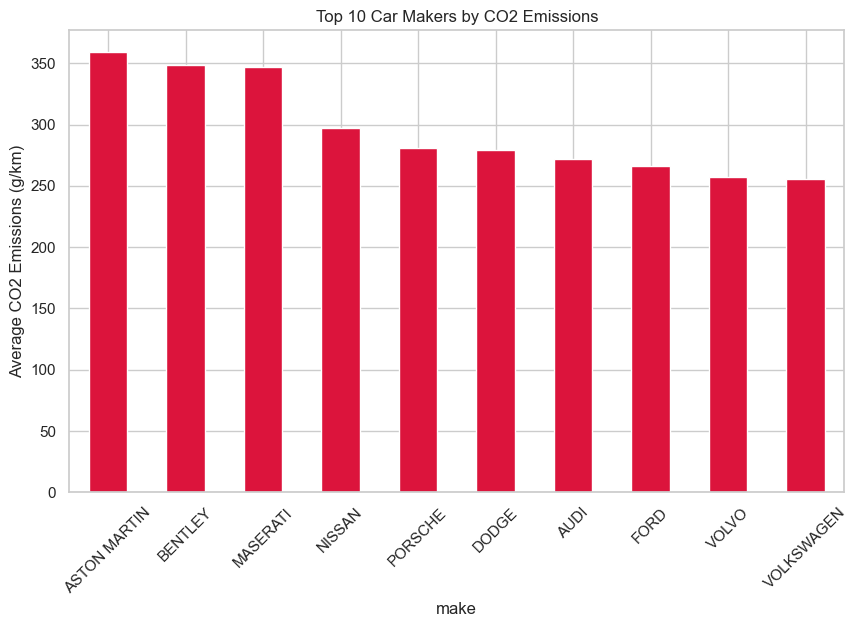

In [55]:


# Top car makers by average CO2 emissions
top_makers = merged_df.groupby('make')['co2emissions'].mean().sort_values(ascending=False).head(10)
top_makers.plot(kind='bar', color='crimson')
plt.title("Top 10 Car Makers by CO2 Emissions")
plt.ylabel("Average CO2 Emissions (g/km)")
plt.xticks(rotation=45)
plt.show()



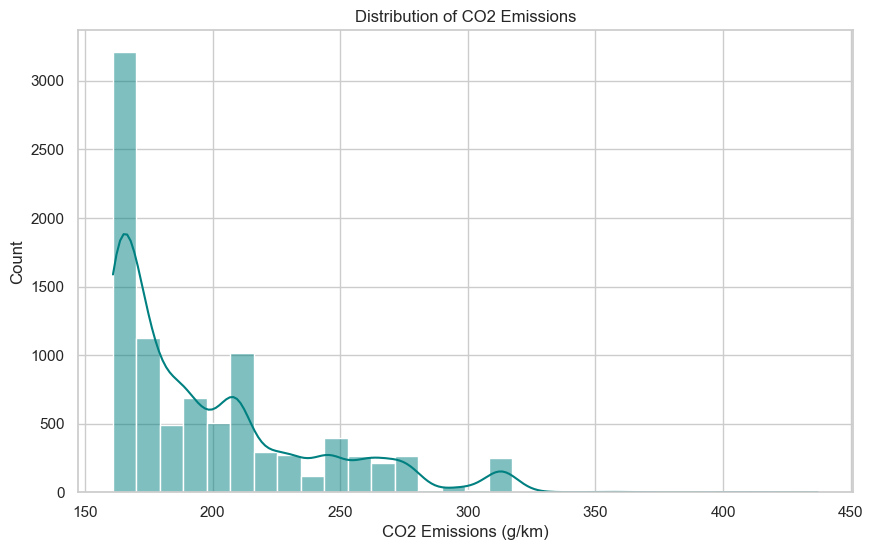

In [57]:
# Distribution of CO2 emissions
sns.histplot(merged_df['co2emissions'], bins=30, kde=True, color='teal')
plt.title("Distribution of CO2 Emissions")
plt.xlabel("CO2 Emissions (g/km)")
plt.show()



<Axes: xlabel='fueltype', ylabel='co2emissions'>

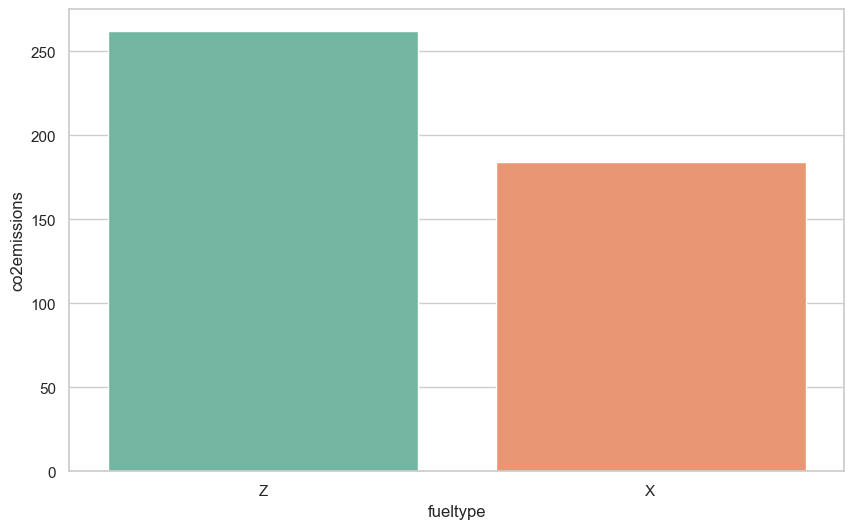

In [59]:

# Fuel type vs CO2 emissions
sns.barplot(
    x='fueltype',
    y='co2emissions',
    data=merged_df,
    errorbar=None,         # Replaces `ci=None`
    palette='Set2',
    hue='fueltype',        # Needed when using `palette`
    legend=False           # Prevents duplicate legend
)


## ii) Performing appropriate machine learning method to classify / cluster the car maker
## / car model according to their carbon emissions using machine learning.

### Research Question 1: How do vehicle characteristics correlate with CO2 emissions?

##### Step 1:  Calculate correlation matrix

In [62]:

correlation = merged_df.corr(numeric_only=True)

# Display correlation with CO2 emissions
print("Correlation with CO2 Emissions:")
print(correlation['co2emissions'].sort_values(ascending=False))



Correlation with CO2 Emissions:
co2emissions                1.000000
fuelconsumption_comb        0.999982
fuelconsumption_city        0.996354
fuelconsumption_hwy         0.986993
enginesize                  0.818346
fueltype_encoded            0.746492
cylinders                   0.709922
fuelconsumption_comb_mpg   -0.979718
modelyear                        NaN
Name: co2emissions, dtype: float64


##### Step 2: Employing Simple Linear Regression

In [69]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.metrics import mean_squared_error


X = merged_df[['enginesize']]
y = merged_df['co2emissions']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = root_mean_squared_error(y, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")



R²: 0.670
RMSE: 22.57


##### Step 3: Multiple Linear Regression

In [71]:
# Select multiple features
features = ['enginesize', 'cylinders', 'fuelconsumption_city',
            'fuelconsumption_hwy', 'fuelconsumption_comb', 'fuelconsumption_comb_mpg']
X_multi = merged_df[features]
y = merged_df['co2emissions']

# Fit model
model_multi = LinearRegression()
model_multi.fit(X_multi, y)

# Predict
y_multi_pred = model_multi.predict(X_multi)

# Coefficients
coefficients = pd.Series(model_multi.coef_, index=features)
print("Model Coefficients:")
print(coefficients)

# Evaluation
r2_multi = r2_score(y, y_multi_pred)
rmse_multi = mean_squared_error(y, y_multi_pred, squared=False)
print(f"R² (Multiple Regression): {r2_multi:.3f}")
print(f"RMSE: {rmse_multi:.2f}")


Model Coefficients:
enginesize                  -0.091403
cylinders                    0.085304
fuelconsumption_city         0.964201
fuelconsumption_hwy          0.785317
fuelconsumption_comb        21.188752
fuelconsumption_comb_mpg    -0.022158
dtype: float64
R² (Multiple Regression): 1.000
RMSE: 0.23


C:\Users\ybzah\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


### Research Question 2: Which car brands/models exhibit the highest and lowest emissions and what trends emerge?

#### Step 1: Group top and bottom 10 emitters by brand and CO2 emissions

In [73]:
# Group by car make (brand), calculate average CO2 emissions
brand_avg = merged_df.groupby('make')['co2emissions'].mean().sort_values()

# Top and bottom 10 emitters
top10 = brand_avg.tail(10)
bottom10 = brand_avg.head(10)


#### Step 2: Clustering Brands by Engine Size & Emissions

In [75]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare brand-level data
brand_data = merged_df.groupby('make')[['enginesize', 'co2emissions']].mean().reset_index()

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(brand_data[['enginesize', 'co2emissions']])

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
brand_data['Cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\ybzah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant numeric features
features = ['enginesize', 'cylinders', 'fuelconsumption_city', 'fuelconsumption_hwy', 
            'fuelconsumption_comb', 'fuelconsumption_comb_mpg', 'co2emissions']

# Correlation matrix
corr = merged_df[features].corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Vehicle Features and CO2 Emissions')
plt.show()



In [ ]:
sns.scatterplot(data=merged_df, x='enginesize', y='co2emissions', alpha=0.6)
plt.title('Engine Size vs CO2 Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()


In [ ]:

sns.scatterplot(data=merged_df, x='fuelconsumption_city', y='co2emissions', alpha=0.6, color='green')
plt.title('City Fuel Consumption vs CO₂ Emissions')
plt.xlabel('City Fuel Consumption (L/100km)')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show()


Which car brands/models exhibit the highest and lowest emissions and what trends emerge?

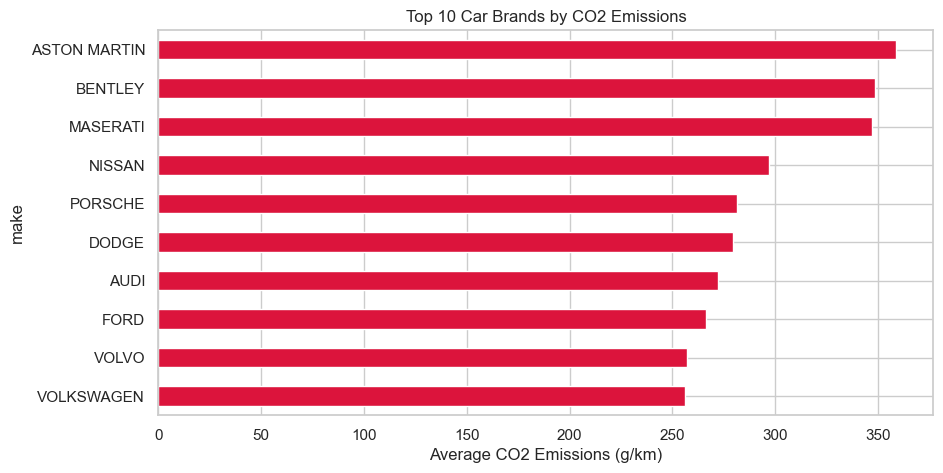

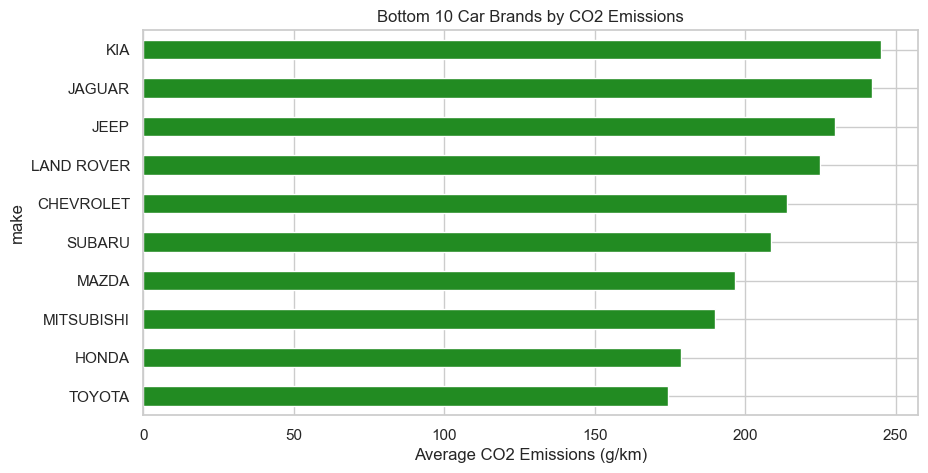

In [42]:
# Group by car make (brand), calculate average CO2 emissions
brand_avg = merged_df.groupby('make')['co2emissions'].mean().sort_values()

# Top and bottom 10 emitters
top10 = brand_avg.tail(10)
bottom10 = brand_avg.head(10)

# Top 10 highest emitters
plt.figure(figsize=(10, 5))
top10.plot(kind='barh', color='crimson')
plt.title('Top 10 Car Brands by CO2 Emissions')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.show()

# Bottom 10 lowest emitters
plt.figure(figsize=(10, 5))
bottom10.plot(kind='barh', color='forestgreen')
plt.title('Bottom 10 Car Brands by CO2 Emissions')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.show()



C:\Users\ybzah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


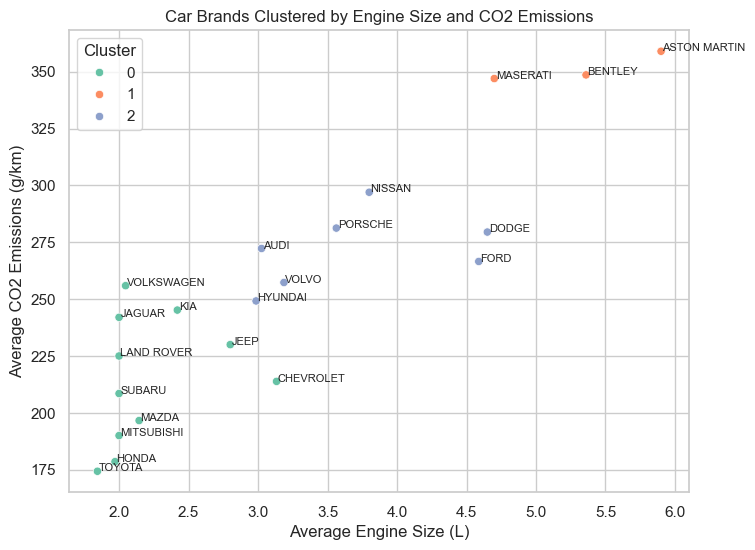

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Prepare brand-level data
brand_data = merged_df.groupby('make')[['enginesize', 'co2emissions']].mean().reset_index()

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(brand_data[['enginesize', 'co2emissions']])

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
brand_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Scatter plot with clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=brand_data, x='enginesize', y='co2emissions', hue='Cluster', palette='Set2')
for _, row in brand_data.iterrows():
    plt.text(row['enginesize'] + 0.01, row['co2emissions'], row['make'], fontsize=8)
plt.title('Car Brands Clustered by Engine Size and CO2 Emissions')
plt.xlabel('Average Engine Size (L)')
plt.ylabel('Average CO2 Emissions (g/km)')
plt.show()


### Research Question 3: How do different fuel types affect CO₂ emissions in vehicles?

For this question, we use classification because we want to Predict if a diesel car is high or low emission based on features.
Now, we just want to identify how many data in the dataset has been correctly classified 

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


# Step 1: Create emission categories
def categorize_emission(co2):
    if co2 < 150:
        return 'Low'
    elif 150 <= co2 < 200:
        return 'Medium'
    else:
        return 'High'

merged_df['emission_class'] = merged_df['co2emissions'].apply(categorize_emission)

# Step 2: Encode fuel type (input feature)
fuel_encoder = LabelEncoder()
merged_df['fueltype_encoded'] = fuel_encoder.fit_transform(merged_df['fueltype'])

# Step 3: Define input and target
X = merged_df[['fueltype_encoded']]  # input
y = merged_df['emission_class']      # target

# Step 4: Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train a classifier (Random Forest)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 6: Evaluate the model
y_pred = clf.predict(X_test)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[ 332  302]
 [   9 1200]]

Classification Report:
               precision    recall  f1-score   support

        High       0.97      0.52      0.68       634
      Medium       0.80      0.99      0.89      1209

    accuracy                           0.83      1843
   macro avg       0.89      0.76      0.78      1843
weighted avg       0.86      0.83      0.82      1843



**Interpretation of the result** <br>
 From the confusion marrix, we can understand in the dataset there are  
- 332 actual High emissions is correctly predicted as High, and 302 actual High misclassified as Medium
- 9 actual Medium misclassified as High, and 1200 actual Medium correctly predicted as Medium <br>

 From the classification report, we can see that: 
- overall accuracy of this analysis is 83%, which is decent, but the performance varies across classes


### Research Question 4: What is the distribution of CO2 emissions across different vehicle classes (e.g., SUVs, sedans, hybrids), and which class contributes the most to emissions?

We use classification because we want to Predict the Vehicle Class from CO2 Emissions

<Figure size 1200x800 with 0 Axes>

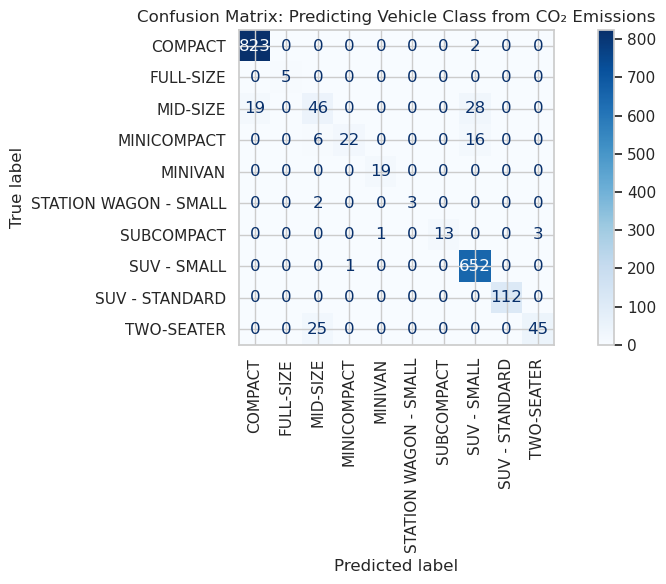

Classification Report:

                       precision    recall  f1-score   support

              COMPACT       0.98      1.00      0.99       825
            FULL-SIZE       1.00      1.00      1.00         5
             MID-SIZE       0.58      0.49      0.53        93
          MINICOMPACT       0.96      0.50      0.66        44
              MINIVAN       0.95      1.00      0.97        19
STATION WAGON - SMALL       1.00      0.60      0.75         5
           SUBCOMPACT       1.00      0.76      0.87        17
          SUV - SMALL       0.93      1.00      0.97       653
       SUV - STANDARD       1.00      1.00      1.00       112
           TWO-SEATER       0.94      0.64      0.76        70

             accuracy                           0.94      1843
            macro avg       0.93      0.80      0.85      1843
         weighted avg       0.94      0.94      0.94      1843



In [112]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out outliers
merged_df = merged_df[merged_df['co2emissions'] < 600]

# Drop rows with missing values (optional)
merged_df = merged_df.dropna(subset=['vehicleclass', 'co2emissions'])

# Create Emission Categories
def emission_category(co2):
    if co2 < 150:
        return 'Low'
    elif 150 <= co2 < 200:
        return 'Medium'
    else:
        return 'High'

merged_df['emission_level'] = merged_df['co2emissions'].apply(emission_category)

# Step 2: Encode Target (Vehicle Class)
from sklearn.preprocessing import LabelEncoder

vehicle_encoder = LabelEncoder()
merged_df['vehicleclass_encoded'] = vehicle_encoder.fit_transform(merged_df['vehicleclass'])

# Step 3: Define Features and Target
X = merged_df[['co2emissions']]  # input feature
y = merged_df['vehicleclass_encoded']  # target


# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Step 5: Train Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


# Step 6: Evaluation
# Confusion Matrix
plt.figure(figsize=(12, 8))
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=vehicle_encoder.classes_, xticks_rotation=90, cmap='Blues')
plt.title("Confusion Matrix: Predicting Vehicle Class from CO₂ Emissions")
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=vehicle_encoder.classes_))


**Interpretation of the result** <br>
 From the confusion matrix, we can understand in the dataset there are
- 823 actual Compact is correctly predicted as compact, and 2 actual compact is misclassified as SUV-Small
- 5 actual full size

 From the confusion matrix, we can understand in the dataset there are
- overall accuracy of this analysis is 94%, which is decent, but the performance varies across classes

## iii. Visualizing our analysis using appropriate visualization.

### Research Question 1: How do vehicle characteristics correlate with CO2 emissions?

In [114]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Vehicle Features and CO2 Emissions')
plt.show()

NameError: name 'corr' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
sns.scatterplot(data=merged_df, x='enginesize', y='co2emissions', alpha=0.6)
plt.title('Engine Size vs CO2 Emissions')
plt.xlabel('Engine Size (L)')
plt.ylabel('CO2 Emissions (g/km)')
plt.show()


### Research Question 2: Which car brands/models exhibit the highest and lowest emissions and what trends emerge?

In [ ]:
# Top 10 highest emitters
plt.figure(figsize=(10, 5))
top10.plot(kind='barh', color='crimson')
plt.title('Top 10 Car Brands by CO2 Emissions')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.show()

# Bottom 10 lowest emitters
plt.figure(figsize=(10, 5))
bottom10.plot(kind='barh', color='forestgreen')
plt.title('Bottom 10 Car Brands by CO2 Emissions')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.show()

In [ ]:
# Scatter plot with clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=brand_data, x='enginesize', y='co2emissions', hue='Cluster', palette='Set2')
for _, row in brand_data.iterrows():
    plt.text(row['enginesize'] + 0.01, row['co2emissions'], row['make'], fontsize=8)
plt.title('Car Brands Clustered by Engine Size and CO2 Emissions')
plt.xlabel('Average Engine Size (L)')
plt.ylabel('Average CO2 Emissions (g/km)')
plt.show()

### Research Question 3: How do different fuel types affect CO₂ emissions in vehicles?

Descriptive Statistics by Fuel Type:
            count        mean        std    min    25%    50%    75%    max
fueltype                                                                  
X         7637.0  184.072149  24.569300  161.0  166.0  175.0  198.0  301.0
Z         1575.0  261.929524  32.662254  196.0  235.0  267.0  276.0  437.0


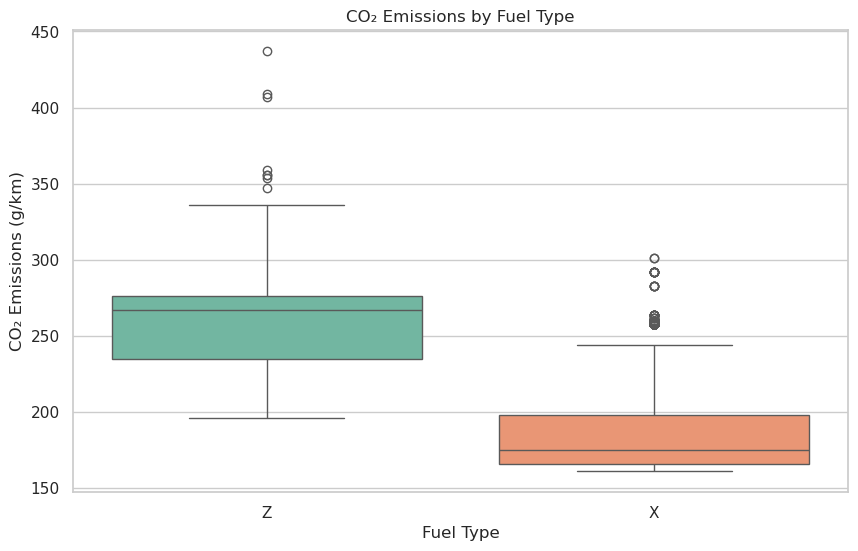

In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway

plt.rcParams['font.family'] = 'DejaVu Sans'  # Fix font for subscript

# Filter extreme values
merged_df = merged_df[merged_df['co2emissions'] < 600]

# Summary Stats
group_stats = merged_df.groupby('fueltype')['co2emissions'].describe()
print("Descriptive Statistics by Fuel Type:\n", group_stats)

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, x='fueltype', y='co2emissions', hue='fueltype', palette='Set2', legend=False)
plt.title('CO₂ Emissions by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('CO₂ Emissions (g/km)')
plt.show()


### Research Question 4: What is the distribution of CO2 emissions across different vehicle classes (e.g., SUVs, sedans, hybrids), and which class contributes the most to emissions?


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Remove extreme outliers
merged_df = merged_df[merged_df['co2emissions'] < 600]

# Drop NA in vehicleclass or emissions
merged_df = merged_df.dropna(subset=['vehicleclass', 'co2emissions'])

sns.set(style='whitegrid')

# 2. Barplot: Total & Mean CO₂ by class
summary = merged_df.groupby('vehicleclass')['co2emissions'].agg(['count', 'mean', 'sum']).sort_values(by='sum', ascending=False)

# Total emissions
plt.figure(figsize=(10, 5))
sns.barplot(x=summary.index, y=summary['mean'], hue=summary.index, palette='coolwarm', legend=False)
plt.title("Total CO2 Emissions by Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("Total CO2 (g/km)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
